# Detecting Price Jumps in Intraday Returns

**Chapter 3: Market Microstructure**

**Docker image**: `ml4t`

## Purpose

Realized intraday variance mixes two distinct processes: a continuous
diffusive component driven by the steady arrival of small order-flow
innovations, and a discrete jump component driven by news, scheduled
announcements, and large block trades. This notebook separates the two
on AlgoSeek NASDAQ-100 minute bars using bipower variation
(Barndorff-Nielsen and Shephard, 2004) for the continuous part and the
Lee–Mykland (2008) nonparametric test to time individual jumps. The
resulting daily features — jump count, signed jump variance, jump share
of realized variance — feed directly into the label-conditioning logic
of Chapter 7 and the volatility-regime features of Chapter 8.

## Learning Objectives

- Decompose daily realized variance into continuous and jump components
  via bipower variation
- Apply the Lee–Mykland test to flag individual jumps with a
  leakage-free, multiple-testing-aware critical value
- Quantify how concentrated jumps are in time of day and across the
  trading year
- Show why a naive |z|>k threshold over-detects in low-vol regimes and
  under-detects in high-vol regimes
- Materialize a per-symbol, per-day jump-feature panel ready for
  downstream feature engineering

## Book reference

Section §3.5, *Detecting Price Jumps in Intraday Returns*.

## Prerequisites

- AlgoSeek TAQ minute bars under
  `data/equities/market/nasdaq100/minute_bars/year=YYYY/month=MM.parquet`
  (Hive-partitioned), loaded via `load_nasdaq100_bars`.
- Companion: `13_algoseek_minute_bars_eda` for raw-bar microstructure
  schema.

In [1]:
"""Lee–Mykland jump detection on AlgoSeek minute bars."""

from __future__ import annotations

import warnings

warnings.filterwarnings("ignore")

import math

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from data import load_nasdaq100_bars
from utils.paths import get_output_dir

In [2]:
# AlgoSeek preserves historical tickers — for 2020 the Meta entry is "FB"
# (the symbol change to "META" landed in mid-2022). load_nasdaq100_bars will
# return zero rows for "META" on 2020 dates.
SYMBOLS = ["AMD", "AMZN", "FB"]
START_DATE = "2020-01-01"
END_DATE = "2020-12-31"
BAR_MINUTES = 5  # Bar frequency in minutes
LEE_MYKLAND_K = 12  # Within-session local-volatility window (~60 min at 5-min)
JUMP_ALPHA = 0.01  # Family-wise significance level for the daily jump test
NAIVE_Z_THRESHOLD = 4.0  # Naive comparison rule: flag |return / rolling_std| > NAIVE_Z

In [3]:
OUTPUT_DIR = get_output_dir(3, "jump_features")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Bipower variation theoretical constant: E[|Z|] = sqrt(2/pi) for Z ~ N(0,1)
MU1 = math.sqrt(2.0 / math.pi)
BARS_PER_DAY = (16 - 9.5) * 60 // BAR_MINUTES  # Regular hours, 78 at 5-min

## 1. Load minute bars and compute log returns

We restrict to regular hours (09:30–16:00 ET) so that the diffusion
assumption underlying both bipower variation and the Lee–Mykland test
is not contaminated by extended-session stale quotes. Log returns are
computed per symbol-day to avoid bridging the overnight gap, which
behaves as a jump but is not the object of intraday inference.

In [4]:
bars = (
    load_nasdaq100_bars(
        frequency=f"{BAR_MINUTES}m",
        symbols=SYMBOLS,
        start_date=START_DATE,
        end_date=END_DATE,
        regular_hours=True,
    )
    .sort(["symbol", "timestamp"])
    .with_columns(date=pl.col("timestamp").dt.date())
)
per_symbol_days = bars.group_by("symbol").agg(n_days=pl.col("date").n_unique())
missing = [s for s in SYMBOLS if s not in set(per_symbol_days["symbol"].to_list())]
if missing:
    raise ValueError(
        f"load_nasdaq100_bars returned zero rows for {missing}; check the ticker "
        f"history (e.g. FB→META in mid-2022) against the date window."
    )
max_days = per_symbol_days["n_days"].max()
short = per_symbol_days.filter(pl.col("n_days") < 0.5 * max_days)
if short.height:
    raise ValueError(
        f"Coverage gap: {short.to_dicts()} cover <50% of the longest-symbol session "
        f"count ({max_days}); a window-shift bug may have left a ticker partially "
        f"unavailable in the requested range."
    )

returns = bars.with_columns(
    log_return=(pl.col("close").log() - pl.col("close").log().shift(1)).over(["symbol", "date"]),
).drop_nulls("log_return")

print(f"Bars loaded: {bars.height:,}  symbols: {returns['symbol'].n_unique()}")
print(f"Trading days: {returns['date'].n_unique():,}  bars/day target: {int(BARS_PER_DAY)}")

Bars loaded: 59,177  symbols: 3
Trading days: 253  bars/day target: 78


## 2. Realized variance and bipower variation

For day $d$ with $n$ intraday log returns $r_1, \dots, r_n$, the
realized variance is
$$\mathrm{RV}_d = \sum_{i=1}^{n} r_i^2,$$
which is a consistent estimator of total quadratic variation —
continuous *plus* squared jumps. The bipower variation,
$$\mathrm{BV}_d = \mu_1^{-2} \sum_{i=2}^{n} |r_i| \, |r_{i-1}|, \qquad \mu_1 = \sqrt{2/\pi},$$
is jump-robust: a single large $|r_i|$ is multiplied by its small
neighbor and contributes negligibly. The gap
$\max(\mathrm{RV}_d - \mathrm{BV}_d, 0)$ is therefore an estimate of
the jump-attributable variance on day $d$.

In [5]:
daily = (
    returns.group_by(["symbol", "date"])
    .agg(
        rv=(pl.col("log_return") ** 2).sum(),
        bv=(pl.col("log_return").abs() * pl.col("log_return").abs().shift(1)).sum() / (MU1**2),
        n_bars=pl.len(),
    )
    .with_columns(
        jump_var=(pl.col("rv") - pl.col("bv")).clip(lower_bound=0.0),
        jump_share_rv=((pl.col("rv") - pl.col("bv")).clip(lower_bound=0.0) / pl.col("rv")).clip(
            0, 1
        ),
    )
)
daily.describe()

statistic,symbol,date,rv,bv,n_bars,jump_var,jump_share_rv
str,str,str,f64,f64,f64,f64,f64
"""count""","""759""","""759""",759.0,759.0,759.0,759.0,759.0
"""null_count""","""0""","""0""",0.0,0.0,0.0,0.0,0.0
"""mean""",null,"""2020-07-02 12:42:41.264822""",0.000562,0.000537,76.967062,0.000042,0.073119
"""std""",null,null,0.000786,0.000765,0.252106,0.000123,0.092732
"""min""","""AMD""","""2020-01-02""",0.000032,0.00003,75.0,0.0,0.0
"""25%""",null,"""2020-04-02""",0.00019,0.000175,77.0,0.0,0.0
"""50%""",null,"""2020-07-02""",0.000325,0.000309,77.0,0.000009,0.038159
"""75%""",null,"""2020-10-01""",0.000606,0.000572,77.0,0.000036,0.117594
"""max""","""FB""","""2020-12-31""",0.007036,0.0057,77.0,0.001536,0.802348


Annualized, BV gives the continuous-volatility floor of each name and
the jump-variance share quantifies how much of the total annual
realized variance is attributable to discrete jumps rather than
diffusion.

In [6]:
annual_summary = (
    daily.group_by("symbol")
    .agg(
        rv_annual=pl.col("rv").sum(),
        bv_annual=pl.col("bv").sum(),
        jump_var_annual=pl.col("jump_var").sum(),
    )
    .with_columns(
        jump_share_annual=pl.col("jump_var_annual") / pl.col("rv_annual"),
        cont_vol_annual=(pl.col("bv_annual").sqrt()),
        rv_vol_annual=(pl.col("rv_annual").sqrt()),
    )
)
annual_summary

symbol,rv_annual,bv_annual,jump_var_annual,jump_share_annual,cont_vol_annual,rv_vol_annual
str,f64,f64,f64,f64,f64,f64
"""AMZN""",0.097087,0.088937,0.010059,0.103609,0.298224,0.311587
"""AMD""",0.209753,0.20366,0.014189,0.067646,0.451287,0.457988
"""FB""",0.119724,0.115228,0.007429,0.062049,0.339453,0.346012


## 3. The Lee–Mykland jump test

Lee and Mykland (2008) construct a test that times jumps to the bar.
For bar $i$ within a session of $n$ bars they form a standardized statistic
$$L_i = \frac{r_i}{\hat\sigma_i}, \qquad
  \hat\sigma_i^2 = \frac{1}{K-2}\sum_{j=i-K+2}^{i-1} |r_j|\,|r_{j-1}|,$$
where $\hat\sigma_i$ is a local bipower volatility built from a window
of $K$ prior returns *within the same session* — it adapts to slow-moving
intraday volatility regimes and is robust to the jumps it is trying to
detect. Building the window per session avoids bridging the overnight
gap, which behaves as a jump and would contaminate the local-volatility
denominator for the first $K$ bars of each day. The trade-off is that
the first $K-1$ bars of every session are not directly testable.

Under the no-jump-at-$i$ null and a continuous-diffusion alternative,
$\max_i |L_i|$ over the daily session converges to a Gumbel distribution.
The rejection rule at level $\alpha$ is
$$|L_i| > S_n \beta^*(\alpha) + C_n, \qquad
  C_n = \frac{(2\log n)^{1/2}}{\mu_1} - \frac{\log\pi + \log\log n}{2\mu_1 (2\log n)^{1/2}}, \;
  S_n = \frac{1}{\mu_1 (2\log n)^{1/2}},$$
and $\beta^*(\alpha) = -\log(-\log(1-\alpha))$. The multiple-testing
burden is absorbed by the $n$-dependent constants, not by an ad-hoc
Bonferroni adjustment. Lee and Mykland recommend $K \approx \sqrt n$
(≈9 for 78 5-minute bars per day); we use $K = 12$ as a slightly more
conservative window.

In [7]:
def gumbel_threshold(n: int, alpha: float) -> float:
    """Lee–Mykland critical value for n bars per session at level alpha."""
    c_n = (np.sqrt(2 * np.log(n)) / MU1) - (np.log(np.pi) + np.log(np.log(n))) / (
        2 * MU1 * np.sqrt(2 * np.log(n))
    )
    s_n = 1.0 / (MU1 * np.sqrt(2 * np.log(n)))
    beta_star = -np.log(-np.log(1 - alpha))
    return s_n * beta_star + c_n


def lee_mykland_jumps_session(rets: pl.DataFrame, k: int, threshold: float) -> pl.DataFrame:
    """Apply Lee–Mykland (2008) per (symbol, date) so the rolling window
    of K-2 pair products is built only from same-session bars.

    Returns the input frame with three columns appended: L_stat,
    sigma_local, is_jump. The first K-1 bars of each session have NaN
    sigma_local (no within-session history yet) and is_jump=False.
    """
    sessions: list[pl.DataFrame] = []
    for (_sym, _date), session in rets.group_by(["symbol", "date"], maintain_order=True):
        r = session["log_return"].to_numpy()
        n_obs = r.shape[0]
        sigma_hat = np.full(n_obs, np.nan)
        if n_obs >= k:
            abs_r = np.abs(r)
            # pair_prod[j] = |r_{j}| * |r_{j-1}| for j = 1 .. n_obs-1, same-session
            pair_prod = abs_r[1:] * abs_r[:-1]
            ps_cum = np.concatenate(([0.0], np.cumsum(pair_prod)))
            # For bar i (i >= k-1, 0-indexed), window uses pair_prod[i-k+1 .. i-2]
            # (k-2 terms ending at bar i-1); first testable bar is index k-1, so
            # exactly K-1 leading bars per session carry NaN sigma_local.
            idx = np.arange(k - 1, n_obs)
            sigma_sq = (ps_cum[idx - 1] - ps_cum[idx - k + 1]) / (k - 2)
            sigma_hat[idx] = np.sqrt(np.maximum(sigma_sq, 0.0))
        # NaN sigma_local → NaN L → comparison yields False; no explicit guard needed.
        L = r / sigma_hat
        sessions.append(
            session.with_columns(
                L_stat=pl.Series(L),
                sigma_local=pl.Series(sigma_hat),
                is_jump=pl.Series(np.abs(L) > threshold),
            )
        )
    return pl.concat(sessions)

In [8]:
# Multiple-testing constants depend on bars per session; computed once across
# all (symbol, date) groups so every bar is tested against the same threshold.
n_per_session = returns.group_by(["symbol", "date"]).len()["len"].to_numpy()
N_PER_SESSION = int(np.median(n_per_session))
threshold_used = gumbel_threshold(N_PER_SESSION, JUMP_ALPHA)
flagged = lee_mykland_jumps_session(returns, k=LEE_MYKLAND_K, threshold=threshold_used)
jumps = flagged.filter(pl.col("is_jump"))
print(f"Bars per session (median): {N_PER_SESSION}")
print(f"Lee–Mykland critical value at α={JUMP_ALPHA}: {threshold_used:.3f}")
print(f"Jumps flagged: {jumps.height:,} across {flagged['symbol'].n_unique()} symbols")
print(
    f"Jumps per symbol-day: {jumps.height / max(1, flagged.group_by(['symbol', 'date']).len().height):.2f}"
)

Bars per session (median): 77
Lee–Mykland critical value at α=0.01: 5.095
Jumps flagged: 282 across 3 symbols
Jumps per symbol-day: 0.37


## 4. How often do jumps fire and how big are they?

A symbol-day typically sees a handful of test rejections; days with
scheduled news cluster materially higher. The signed magnitude of
the underlying log return distinguishes upside surprises from
downside.

In [9]:
daily_jump_counts = (
    flagged.group_by(["symbol", "date"]).agg(
        jump_count=pl.col("is_jump").sum(),
        signed_jump_var=pl.when(pl.col("is_jump"))
        .then(pl.col("log_return") ** 2 * pl.col("log_return").sign())
        .otherwise(0.0)
        .sum(),
    )
).join(
    daily.select("symbol", "date", "rv", "bv", "jump_var", "jump_share_rv"), on=["symbol", "date"]
)
print(daily_jump_counts.describe())

shape: (9, 9)
┌────────────┬────────┬─────────────┬────────────┬───┬──────────┬──────────┬──────────┬────────────┐
│ statistic  ┆ symbol ┆ date        ┆ jump_count ┆ … ┆ rv       ┆ bv       ┆ jump_var ┆ jump_share │
│ ---        ┆ ---    ┆ ---         ┆ ---        ┆   ┆ ---      ┆ ---      ┆ ---      ┆ _rv        │
│ str        ┆ str    ┆ str         ┆ f64        ┆   ┆ f64      ┆ f64      ┆ f64      ┆ ---        │
│            ┆        ┆             ┆            ┆   ┆          ┆          ┆          ┆ f64        │
╞════════════╪════════╪═════════════╪════════════╪═══╪══════════╪══════════╪══════════╪════════════╡
│ count      ┆ 759    ┆ 759         ┆ 759.0      ┆ … ┆ 759.0    ┆ 759.0    ┆ 759.0    ┆ 759.0      │
│ null_count ┆ 0      ┆ 0           ┆ 0.0        ┆ … ┆ 0.0      ┆ 0.0      ┆ 0.0      ┆ 0.0        │
│ mean       ┆ null   ┆ 2020-07-02  ┆ 0.371542   ┆ … ┆ 0.000562 ┆ 0.000537 ┆ 0.000042 ┆ 0.073119   │
│            ┆        ┆ 12:42:41.26 ┆            ┆   ┆          ┆          ┆ 

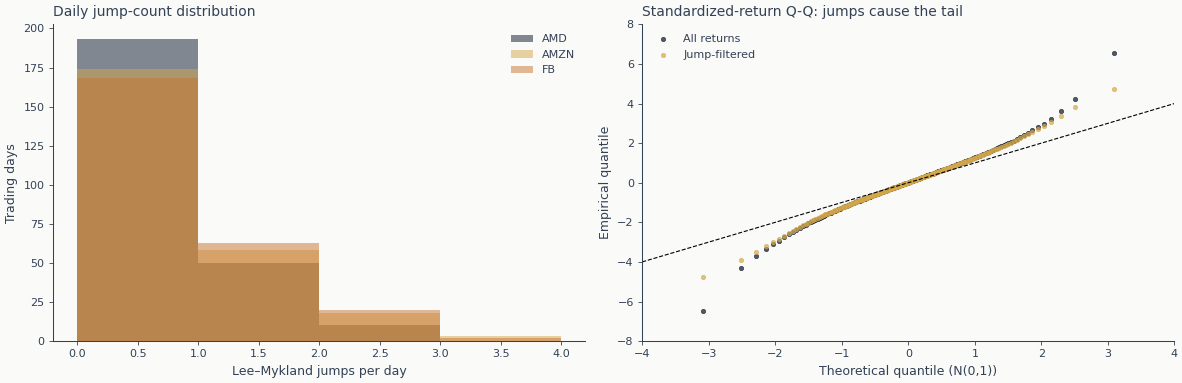

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for sym in SYMBOLS:
    counts = daily_jump_counts.filter(pl.col("symbol") == sym)["jump_count"].to_numpy()
    axes[0].hist(counts, bins=range(0, int(counts.max()) + 2), alpha=0.5, label=sym)
axes[0].set_xlabel("Lee–Mykland jumps per day")
axes[0].set_ylabel("Trading days")
axes[0].set_title("Daily jump-count distribution")
axes[0].legend()

# Q-Q of standardized returns: all vs jump-filtered. sigma_local is NaN for
# the first LEE_MYKLAND_K-1 bars of each session (no within-session window
# yet), so division yields NaN — filter explicitly.
all_z_raw = (flagged["log_return"] / flagged["sigma_local"]).to_numpy()
all_z = all_z_raw[np.isfinite(all_z_raw)]
filt = flagged.filter(~pl.col("is_jump"))
filt_z_raw = (filt["log_return"] / filt["sigma_local"]).to_numpy()
filt_z = filt_z_raw[np.isfinite(filt_z_raw)]
qs = np.linspace(0.001, 0.999, 200)
from scipy.stats import norm  # noqa: PLC0415

norm_q = norm.ppf(qs)
axes[1].scatter(norm_q, np.quantile(all_z, qs), s=10, alpha=0.7, label="All returns")
axes[1].scatter(norm_q, np.quantile(filt_z, qs), s=10, alpha=0.7, label="Jump-filtered")
axes[1].plot([-4, 4], [-4, 4], "k--", lw=0.8)
axes[1].set_xlim(-4, 4)
axes[1].set_ylim(-8, 8)
axes[1].set_xlabel("Theoretical quantile (N(0,1))")
axes[1].set_ylabel("Empirical quantile")
axes[1].set_title("Standardized-return Q-Q: jumps cause the tail")
axes[1].legend()
fig.tight_layout()
fig.show()

## 5. Jumps cluster in time of day

The opening minutes and the close concentrate price discovery: news
released overnight is impounded at the auction, and end-of-day
rebalancing flows produce sharp moves. The session-boundary fix means
the first `LEE_MYKLAND_K - 1` bars of each day (≈55 min) are not
testable, so any "first 30 min" detection here is limited; we report
the share within the testable window and look for the close-of-day
uptick that the test can see in full.

In [11]:
tod = flagged.filter(pl.col("is_jump")).with_columns(
    minute_of_day=pl.col("timestamp").dt.hour().cast(pl.Int32) * 60
    + pl.col("timestamp").dt.minute()
)
tod_hist = tod.group_by("minute_of_day").len().sort("minute_of_day")
all_minutes = (
    flagged.with_columns(
        minute_of_day=pl.col("timestamp").dt.hour().cast(pl.Int32) * 60
        + pl.col("timestamp").dt.minute()
    )
    .group_by("minute_of_day")
    .len()
    .rename({"len": "all_bars"})
    .sort("minute_of_day")
)
tod_rate = tod_hist.join(all_minutes, on="minute_of_day", how="right").with_columns(
    rate_per_1k=pl.col("len").fill_null(0) / pl.col("all_bars") * 1000
)
share_first_30 = tod.filter(pl.col("minute_of_day") < 9 * 60 + 30 + 30).height / tod.height
share_last_30 = tod.filter(pl.col("minute_of_day") >= 16 * 60 - 30).height / tod.height
print(f"Share of jumps in first 30 min: {share_first_30:.1%}")
print(f"Share of jumps in last 30 min:  {share_last_30:.1%}")

Share of jumps in first 30 min: 0.0%
Share of jumps in last 30 min:  26.6%


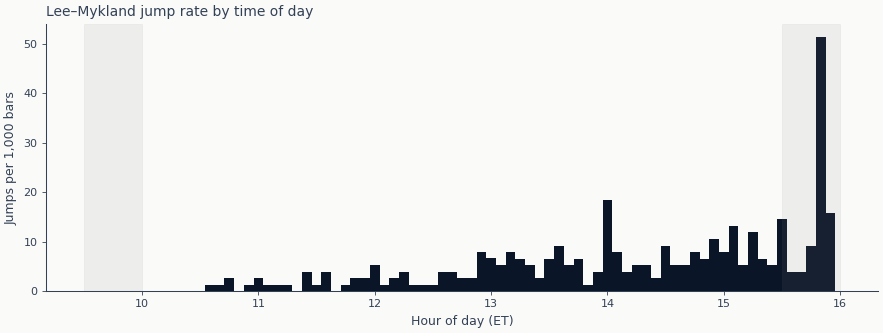

In [12]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(
    tod_rate["minute_of_day"].to_numpy() / 60,
    tod_rate["rate_per_1k"].to_numpy(),
    width=BAR_MINUTES / 60.0,
    edgecolor="none",
)
ax.set_xlabel("Hour of day (ET)")
ax.set_ylabel("Jumps per 1,000 bars")
ax.set_title("Lee–Mykland jump rate by time of day")
ax.axvspan(9.5, 10.0, alpha=0.1, color="grey")
ax.axvspan(15.5, 16.0, alpha=0.1, color="grey")
fig.tight_layout()
fig.show()

## 6. Variance decomposition over the year

Stacking the continuous (bipower) and jump variance components over
time shows that jump contribution is episodic: most days have a small
or zero jump variance, punctuated by clusters around earnings,
macroeconomic releases, and stress periods.

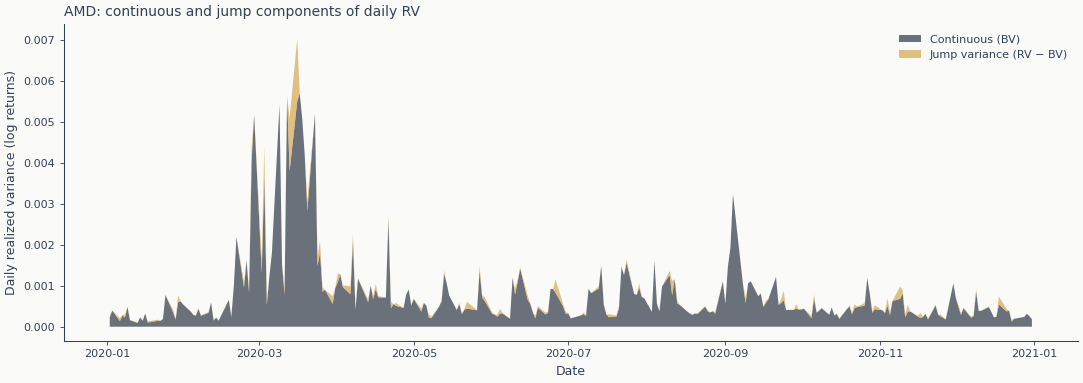

In [13]:
fig, ax = plt.subplots(figsize=(11, 4))
focus = daily.filter(pl.col("symbol") == SYMBOLS[0]).sort("date").to_pandas()
ax.fill_between(focus["date"], 0, focus["bv"], alpha=0.6, label="Continuous (BV)")
ax.fill_between(
    focus["date"],
    focus["bv"],
    focus["bv"] + focus["jump_var"],
    alpha=0.7,
    label="Jump variance (RV − BV)",
)
ax.set_xlabel("Date")
ax.set_ylabel("Daily realized variance (log returns)")
ax.set_title(f"{SYMBOLS[0]}: continuous and jump components of daily RV")
ax.legend()
fig.tight_layout()
fig.show()

## 7. Why the local-volatility adjustment matters

A naive rule that flags any bar with $|r_i / \hat\sigma_d| > 4$, where
$\hat\sigma_d$ is a single daily volatility, ignores time-of-day
volatility shape and slow regime changes. Compared with Lee–Mykland
it over-detects on calm days (the daily $\hat\sigma_d$ is small, so
even modestly elevated bars exceed the fixed $4\hat\sigma_d$
threshold) and under-detects on volatile days (the daily $\hat\sigma_d$
is inflated by the very moves we are trying to flag, so large bars
fail to clear $4\hat\sigma_d$).

In [14]:
daily_sigma = returns.group_by(["symbol", "date"]).agg(daily_std=pl.col("log_return").std())
naive = (
    returns.join(daily_sigma, on=["symbol", "date"])
    .with_columns(naive_z=pl.col("log_return") / pl.col("daily_std"))
    .with_columns(naive_jump=pl.col("naive_z").abs() > NAIVE_Z_THRESHOLD)
)
comparison = (
    flagged.join(naive.select("symbol", "timestamp", "naive_jump"), on=["symbol", "timestamp"])
    .group_by("symbol")
    .agg(
        lm_jumps=pl.col("is_jump").sum(),
        naive_jumps=pl.col("naive_jump").sum(),
        both=(pl.col("is_jump") & pl.col("naive_jump")).sum(),
        lm_only=(pl.col("is_jump") & ~pl.col("naive_jump")).sum(),
        naive_only=(~pl.col("is_jump") & pl.col("naive_jump")).sum(),
    )
)
comparison

symbol,lm_jumps,naive_jumps,both,lm_only,naive_only
str,u32,u32,u32,u32,u32
"""AMZN""",103,48,6,97,42
"""FB""",109,49,6,103,43
"""AMD""",70,55,2,68,53


## 8. Materialize the jump-feature panel

The output is a per-symbol, per-day frame with the features that
downstream chapters consume directly: total jump count, signed jump
variance, and the jump share of total realized variance. These join
cleanly to the bar-level feature panels of Chapters 7–8.

In [15]:
features = daily_jump_counts.select(
    "symbol",
    "date",
    "jump_count",
    "signed_jump_var",
    pl.col("jump_var").alias("jump_variance"),
    pl.col("jump_share_rv").alias("jump_share"),
    pl.col("rv").alias("rv_total"),
    pl.col("bv").alias("continuous_variance"),
).sort(["symbol", "date"])
features.write_parquet(OUTPUT_DIR / "daily_jump_features.parquet")
print(f"Wrote {features.height:,} rows to {OUTPUT_DIR / 'daily_jump_features.parquet'}")
features.head(10)

Wrote 759 rows to 03_market_microstructure/output/jump_features/daily_jump_features.parquet


symbol,date,jump_count,signed_jump_var,jump_variance,jump_share,rv_total,continuous_variance
str,date,u32,f64,f64,f64,f64,f64
"""AMD""",2020-01-02,0,0.0,0.000002,0.006911,0.000234,0.000232
"""AMD""",2020-01-03,1,0.000026,0.0,0.0,0.000351,0.000395
"""AMD""",2020-01-06,0,0.0,0.000074,0.351946,0.00021,0.000136
"""AMD""",2020-01-07,0,0.0,0.000017,0.060024,0.000286,0.000269
"""AMD""",2020-01-08,1,-0.00004,0.000075,0.251563,0.000297,0.000222
"""AMD""",2020-01-09,1,-0.000039,0.0,0.0,0.00046,0.000481
"""AMD""",2020-01-10,1,-0.000011,0.000005,0.030267,0.000164,0.000159
"""AMD""",2020-01-13,0,0.0,0.000019,0.170265,0.000109,0.00009
"""AMD""",2020-01-14,1,-0.000034,0.0,0.0,0.00021,0.00023


## Takeaways

- Realized variance over-states diffusive risk because it absorbs
  jumps; bipower variation gives a jump-robust continuous-variance
  estimate and the difference times jump contribution.
- The Lee–Mykland test fires the multiple-testing-correct number of
  jumps per day in expectation and adapts to time-varying volatility,
  so it is comparable across regimes in a way that fixed-threshold
  rules are not.
- The Lee–Mykland jump rate by time of day shows a clear close-of-day
  uptick within the testable window (the first `LEE_MYKLAND_K - 1` bars
  of each session are not directly testable). See §5 for the printed
  per-window shares. The notebook does not condition on scheduled news
  days; the daily variance decomposition in §6 shows episodic jump
  contribution but is not aligned to an external news calendar.
- The daily features written above plug into Chapter 7 (jump-conditional
  labels and event-time sampling) and Chapter 8 (volatility-regime
  features and feature stratification).